In [1]:
import astropy.units as u
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snewpy.models.ccsn as models
import ipywidgets as widgets

from ipywidgets import interact
from IPython.display import Markdown
from snewpy.neutrino import Flavor
from snewpy.rate_calculator import RateCalculator

from scipy.integrate import quad

import ibd
import es

In [2]:
models.all_models

{snewpy.models.ccsn.Bollig_2016,
 snewpy.models.ccsn.Bugli_2021,
 snewpy.models.ccsn.Fischer_2020,
 snewpy.models.ccsn.Fornax_2019,
 snewpy.models.ccsn.Fornax_2021,
 snewpy.models.ccsn.Fornax_2022,
 snewpy.models.ccsn.Kuroda_2020,
 snewpy.models.ccsn.Mori_2023,
 snewpy.models.ccsn.Nakazato_2013,
 snewpy.models.ccsn.OConnor_2013,
 snewpy.models.ccsn.OConnor_2015,
 snewpy.models.ccsn.Sukhbold_2015,
 snewpy.models.ccsn.Tamborra_2014,
 snewpy.models.ccsn.Walk_2018,
 snewpy.models.ccsn.Walk_2019,
 snewpy.models.ccsn.Warren_2020,
 snewpy.models.ccsn.Zha_2021,
 snewpy.models.presn.Kato_2017,
 snewpy.models.presn.Odrzywolek_2010,
 snewpy.models.presn.Patton_2017,
 snewpy.models.presn.Yoshida_2016}

# Organizar modelos

In [3]:
# Lista modelos de interés
modelos_obj = {
    'Nakazato_2013': models.Nakazato_2013,
    'Sukhbold_2015': models.Sukhbold_2015,
    'Tamborra_2014': models.Tamborra_2014, 
    'Bollig_2016' : models.Bollig_2016
}

catalogo_modelos = {
    nombre: clase.get_param_combinations()
    for nombre, clase in modelos_obj.items()
}

def mostrar_opciones():
    """
    Imprime el catálogo de modelos y la combinación de parámetros disponibles.
    """
    print(f"{'MODELO':<20} | {'COMBINACIONES DISPONIBLES'}")
    print("-" * 60)
    for nombre, combos in catalogo_modelos.items():
        print(f"{nombre:<20} | {len(combos)} combinaciones encontradas.")

# Modelos y total de opciones
mostrar_opciones()

MODELO               | COMBINACIONES DISPONIBLES
------------------------------------------------------------
Nakazato_2013        | 24 combinaciones encontradas.
Sukhbold_2015        | 4 combinaciones encontradas.
Tamborra_2014        | 5 combinaciones encontradas.
Bollig_2016          | 2 combinaciones encontradas.


In [4]:
def listar_combinaciones(nombre_modelo):
    """
    Muestra todas las opciones para un modelo específico.
    """
    combos = catalogo_modelos.get(nombre_modelo)
    if combos:
        df = pd.DataFrame(combos)
        print(f"Opciones disponibles para {nombre_modelo}:")
        display(df)
    else:
        print("Modelo no encontrado.")


# Ejemplo
listar_combinaciones('Sukhbold_2015')

modelo_act = ''

Opciones disponibles para Sukhbold_2015:


,progenitor_mass,eos
0,27.0 solMass,LS220
1,27.0 solMass,SFHo
2,9.6 solMass,LS220
3,9.6 solMass,SFHo


In [5]:
def cargar_modelo(nombre_modelo, indice_comb):
    """
    Instancia un modelo de snewpy usando el diccionario de combinaciones.
    """
    clase_modelo = modelos_obj[nombre_modelo]
    parametros = catalogo_modelos[nombre_modelo][indice_comb]

    global modelo_act
    modelo_act = nombre_modelo
    
    print(f"Cargando {nombre_modelo} con parámetros: {parametros}")
    return clase_modelo(**parametros)



# EJEMPLO
mi_modelo = cargar_modelo('Nakazato_2013', 0)

mi_modelo

Cargando Nakazato_2013 con parámetros: {'progenitor_mass': <Quantity 13. solMass>, 'revival_time': <Quantity 100. ms>, 'metallicity': 0.02, 'eos': 'shen'}


**Nakazato_2013 Model**: nakazato-shen-z0.02-t_rev100ms-s13.0.fits

|Parameter|Value|
|:--------|:----:|
|Progenitor mass | $13$ $\mathrm{M_{\odot}}$|
|Revival time | $100$ $\mathrm{ms}$|
|Metallicity | 0.02 |
|EOS | shen |

# Características espectrales

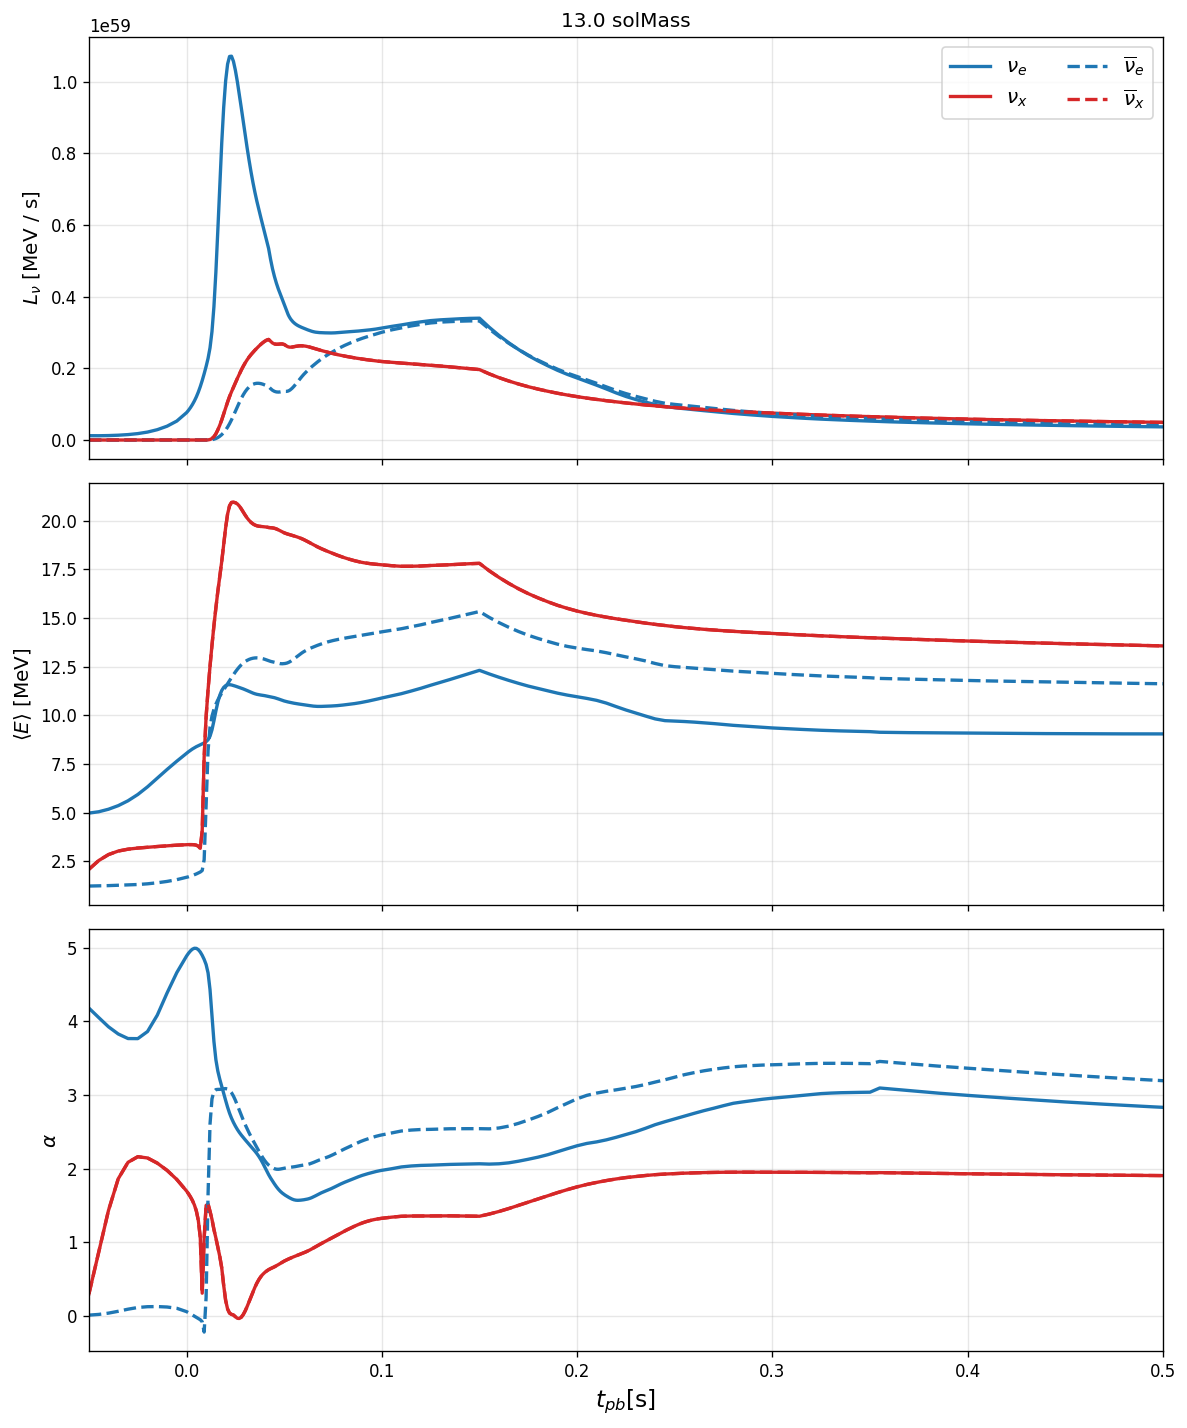

In [6]:
def graficar_cantidades_modelo(modelo):
    """
    Extrae y grafica la luminosidad, energía media y parámetro pinch
    en la neutrinósfera.
    """    
    t = modelo.time
    
    # 3 subplots verticales
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, 
                                        figsize=(10, 12), 
                                        sharex=True, 
                                        dpi=120)
    
    # 1. Luminosidad (MeV/s) 
    for flavor in Flavor:
        ax1.plot(t, modelo.luminosity[flavor].to(u.MeV / u.s), 
                 color='C0' if flavor.is_electron else 'C3',
                 ls='-' if flavor.is_neutrino else '--',
                 lw=2, 
                 label=flavor.to_tex())
        
    ax1.set_ylabel(r'$L_{\nu}$ ' f'[{modelo.luminosity[Flavor.NU_E].to(u.MeV / u.s).unit}]', 
                   fontsize=12)
    ax1.set_title(f'{modelo.metadata.get("Progenitor mass", "CCSN")}')
    ax1.grid(alpha=0.3)
    ax1.legend(loc='upper right', ncol=2, fontsize=12)

    # 2. Energía media (MeV)
    for flavor in Flavor:
        ax2.plot(t, modelo.meanE[flavor].to(u.MeV), 
                 color='C0' if flavor.is_electron else 'C3',
                 ls='-' if flavor.is_neutrino else '--',
                 lw=2)
                 
    ax2.set_ylabel(rf'$\langle E \rangle$ [{modelo.meanE[Flavor.NU_E].to(u.MeV).unit}]', 
                   fontsize=12)
    ax2.grid(alpha=0.3)

    # 3. Parámetro alpha
    for flavor in Flavor:
        ax3.plot(t, modelo.pinch[flavor], 
                 color='C0' if flavor.is_electron else 'C3',
                 ls='-' if flavor.is_neutrino else '--',
                 lw=2)
                 
    ax3.set_ylabel(rf'$\alpha$', 
                   fontsize=12)
    ax3.set_xlabel(r'$t_{pb}$' + f'[{t.unit}]', 
                   fontsize=14)
    ax3.grid(alpha=0.3)

    ax3.set_xlim(-0.05, 0.5) 
    
    plt.tight_layout()
    plt.show()

graficar_cantidades_modelo(mi_modelo)

# Cálculo neutrinósferas
$$
\Large
L_{\nu_{x}} = 4\pi\phi\sigma_{\nu}\,T^{4}_{\nu}R^{2}_{\nu}
$$

$$
\Large
R_{\nu} = \sqrt{\frac{L_{\nu_{x}}}{4\pi\phi\sigma_{\nu}T^{4}_{\nu}}} 
$$

Calculando neutrinósfera para: Nakazato_2013...


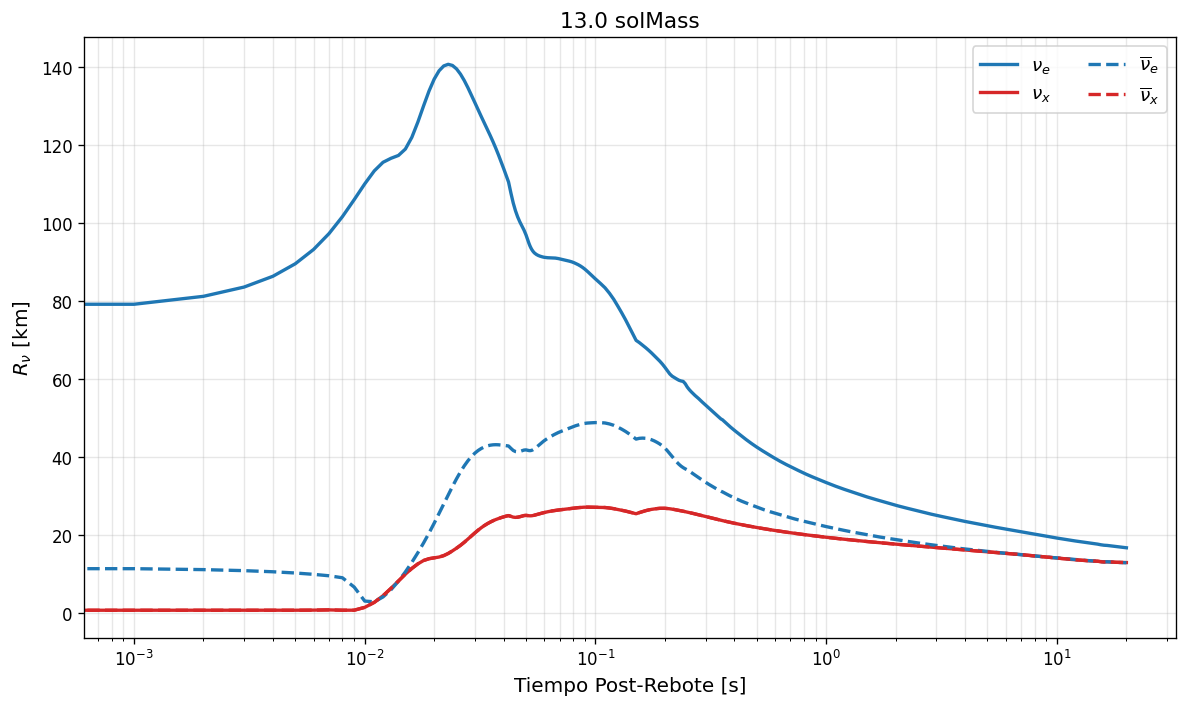

In [7]:
def graficar_radio_neutrinosfera(modelo):
    """
    Calcula y grafica la evolución temporal del radio 
    de la neutrinosfera para el modelo CCSN cargado.
    """
    print(f"Calculando neutrinósfera para: {modelo.__class__.__name__}...")
    
    # Definiciones
    sigmanu = 4.751e+35 * u.erg / (u.MeV**4 * u.cm**2 * u.s)
    phigray = 0.8  # 0.4 - 0.8
    
    # Temperatura efectiva
    tempe = {flavor: energia / 3.1514 for flavor, energia in modelo.meanE.items()}

    radion = {flavor: np.sqrt(luminosidad/(4*np.pi*phigray*sigmanu*(tempe[flavor]**4))).to(u.km)
             for flavor, luminosidad in modelo.luminosity.items()}

    plt.figure(figsize=(10, 6), dpi=120)
    
    for flavor in Flavor:
        plt.plot(modelo.time, radion[flavor], 
                 label=flavor.to_tex(),
                 color='C0' if flavor.is_electron else 'C3',
                 ls='-' if flavor.is_neutrino else '--', lw=2)
                 
    plt.xscale('log')
    plt.xlabel(f'Tiempo Post-Rebote [{modelo.time.unit}]', fontsize=12)
    plt.ylabel(f'$R_\\nu$ [{radion[Flavor.NU_E].unit}]', fontsize=12)
    plt.title(f'{modelo.metadata.get("Progenitor mass", "CCSN")}', 
              fontsize=13)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(loc='upper right', ncol=2, fontsize=11)
    
    plt.tight_layout()
    plt.show()

graficar_radio_neutrinosfera(mi_modelo)

# Flujos en Tierra para ambas jerarquías (Manual)

In [8]:
"""
DEFINICIONES
"""
# Cada opción del dropdown tiene un P_H asociado
diccionario_PH = {
    'Adiabática (PH = 0)':     0.0,
    'Mixta (PH = 0.5)':        0.5,
    'No Adiabática (PH = 1)':  1.0,
}

energiatest = np.linspace(0.1, 60, 200) * u.MeV
# energiatest = np.arange(0.1, 60.5, 0.5) * u.MeV # bins?

# distancia = (10*u.kpc).to(u.cm)
# factor_T = 1/(4*np.pi*distancia**2)
t = mi_modelo.time

# Diccionario con el espectro inicial (neutrinósfera) en todo el tiempo de la simulación 
espectro_aux = mi_modelo.get_initial_spectra(t, energiatest)
espectro = {flavor: data.to(1/(u.MeV*u.s)) for flavor, data in espectro_aux.items()}

# Flujos en Tierra
flujo_tierra = {sabor: None for sabor in Flavor}

def calcular_probabilidades(P_H, jerarquia):
    """
    Calcula p y p_bar usando las fórmulas de Dighe-Smirnov con P_L = 0.

    NMO:
        p     = |Ue2|² * P_H + |Ue3|² * (1 - P_H)
        p_bar = |Ue1|²
    IMO:
        p     = |Ue2|²
        p_bar = |Ue1|² * P_H + |Ue3|² * (1 - P_H)
    """
    angulos = {
        'Normal (NMO)':    (33.76, 8.62, 43.29),
        'Invertida (IMO)': (33.76, 8.65, 47.90),
    }
    
    t12, t13, t23 = [np.deg2rad(a) for a in angulos[jerarquia]]

    Ue1_sq = np.cos(t12)**2 * np.cos(t13)**2
    Ue2_sq = np.sin(t12)**2 * np.cos(t13)**2
    Ue3_sq = np.sin(t13)**2

    if jerarquia == 'Normal (NMO)':
        p     = Ue2_sq * P_H + Ue3_sq * (1.0 - P_H)
        p_bar = Ue1_sq

    elif jerarquia == 'Invertida (IMO)':
        p     = Ue2_sq
        p_bar = Ue1_sq * P_H + Ue3_sq * (1.0 - P_H)

    return p, p_bar


def cantidades_en_tierra(P_H, distancia_kpc = 10):
    """
    Calcula los flujos en la Tierra (flujo_nmo, flujo_imo) a partir de una probabilidad ph
    """
    distancia = (distancia_kpc*u.kpc).to(u.cm)
    factor_T = 1/(4*np.pi*distancia**2)

    psurvival_nmo, psurvival_bar_nmo = calcular_probabilidades(P_H, 'Normal (NMO)')
    psurvival_imo, psurvival_bar_imo = calcular_probabilidades(P_H, 'Invertida (IMO)')

    # NMO
    flujo_tierra_nmo = {sabor: None for sabor in Flavor}
    
    # Flujo en Tierra (tiempo x energía)
    flujo_tierra_nmo[Flavor.NU_E] = (psurvival_nmo*espectro[Flavor.NU_E] + (1-psurvival_nmo)*espectro[Flavor.NU_X]) * factor_T
    flujo_tierra_nmo[Flavor.NU_X] = (1/2)*((1-psurvival_nmo)*espectro[Flavor.NU_E] + (1+psurvival_nmo)*espectro[Flavor.NU_X]) * factor_T
    flujo_tierra_nmo[Flavor.NU_E_BAR] = (psurvival_bar_nmo*espectro[Flavor.NU_E_BAR] + (1-psurvival_bar_nmo)*espectro[Flavor.NU_X_BAR]) * factor_T
    flujo_tierra_nmo[Flavor.NU_X_BAR] = (1/2)*((1-psurvival_bar_nmo)*espectro[Flavor.NU_E_BAR] + (1+psurvival_bar_nmo)*espectro[Flavor.NU_X_BAR]) * factor_T

    # IMO
    flujo_tierra_imo = {sabor: None for sabor in Flavor}
    
    # Flujo en Tierra (tiempo x energía)
    flujo_tierra_imo[Flavor.NU_E] = (psurvival_imo*espectro[Flavor.NU_E] + (1-psurvival_imo)*espectro[Flavor.NU_X]) * factor_T
    flujo_tierra_imo[Flavor.NU_X] = (1/2)*((1-psurvival_imo)*espectro[Flavor.NU_E] + (1+psurvival_imo)*espectro[Flavor.NU_X]) * factor_T
    flujo_tierra_imo[Flavor.NU_E_BAR] = (psurvival_bar_imo*espectro[Flavor.NU_E_BAR] + (1-psurvival_bar_imo)*espectro[Flavor.NU_X_BAR]) * factor_T
    flujo_tierra_imo[Flavor.NU_X_BAR] = (1/2)*((1-psurvival_bar_imo)*espectro[Flavor.NU_E_BAR] + (1+psurvival_bar_imo)*espectro[Flavor.NU_X_BAR]) * factor_T


    return flujo_tierra_nmo, flujo_tierra_imo


flujo_tierra

{<Flavor.NU_E: 0>: None,
 <Flavor.NU_X: 1>: None,
 <Flavor.NU_E_BAR: 2>: None,
 <Flavor.NU_X_BAR: 3>: None}

In [9]:
"""
PLOT INTERACTIVO
"""
def flujo_tierra_widget(tiempoS, nombre_transformacion, ordenamiento, distancia_kpc=10):

    display(f"Tiempo: {t[tiempoS]}")

    distancia = (distancia_kpc*u.kpc).to(u.cm)
    factor_T = 1/(4*np.pi*distancia**2)

    # Escenario P_H y probabilidades
    P_H = diccionario_PH[nombre_transformacion]
    psurvival, psurvival_bar = calcular_probabilidades(P_H, ordenamiento)

    # Espectro inicial (neutrinósfera) en cada tiempoS
    espectro_temp = {flavor: data[tiempoS] for flavor, data in espectro.items()}

    # # Flujos en Tierra deprecated. 
    # Ahora no se guarda solo un slice sino que se guarda el flujo en todo el trayecto y se hace el slice al graficar
    
    # flujo_tierra = {sabor: None for sabor in Flavor}
    # # Conservación de flujo y factor geométrico
    # flujo_tierra[Flavor.NU_E] = (psurvival*espectro_temp[Flavor.NU_E] + (1-psurvival)*espectro_temp[Flavor.NU_X]) * factor_T
    # flujo_tierra[Flavor.NU_X] = (1/2)*((1-psurvival)*espectro_temp[Flavor.NU_E] + (1+psurvival)*espectro_temp[Flavor.NU_X]) * factor_T
    # flujo_tierra[Flavor.NU_E_BAR] = (psurvival_bar*espectro_temp[Flavor.NU_E_BAR] + (1-psurvival_bar)*espectro_temp[Flavor.NU_X_BAR]) * factor_T
    # flujo_tierra[Flavor.NU_X_BAR] = (1/2)*((1-psurvival_bar)*espectro_temp[Flavor.NU_E_BAR] + (1+psurvival_bar)*espectro_temp[Flavor.NU_X_BAR]) * factor_T

    # Flujos en Tierra
    global flujo_tierra # Se puede quitar, solo se usó para poder manejar el flujo calculado aquí por fuera de la función. 
                        # Una vez creado el dict por fuera, se calcula de forma independiente en cada widget interactivo. 
    
    # Conservación de flujo y factor geométrico
    flujo_tierra[Flavor.NU_E] = (psurvival*espectro[Flavor.NU_E] + (1-psurvival)*espectro[Flavor.NU_X]) * factor_T
    flujo_tierra[Flavor.NU_X] = (1/2)*((1-psurvival)*espectro[Flavor.NU_E] + (1+psurvival)*espectro[Flavor.NU_X]) * factor_T
    flujo_tierra[Flavor.NU_E_BAR] = (psurvival_bar*espectro[Flavor.NU_E_BAR] + (1-psurvival_bar)*espectro[Flavor.NU_X_BAR]) * factor_T
    flujo_tierra[Flavor.NU_X_BAR] = (1/2)*((1-psurvival_bar)*espectro[Flavor.NU_E_BAR] + (1+psurvival_bar)*espectro[Flavor.NU_X_BAR]) * factor_T
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

    # Espectro inicial en la neutrinósfera
    for flavor in Flavor:
        ax1.plot(
            energiatest,
            espectro_temp[flavor],
            color = 'C0' if flavor.is_electron else 'C3',
            ls    = '-'  if flavor.is_neutrino  else '--',
            lw    = 2,
            label = flavor.to_tex()
        )

    ax1.set_title('Espectro Inicial (Neutrinósfera)')
    ax1.set_xlabel(f'E [{energiatest.unit}]')
    ax1.set_ylabel(f'[{espectro_temp[Flavor.NU_E][0].unit}]')
    ax1.grid(alpha=0.3)
    ax1.legend(loc='upper right', ncol=2, fontsize=11)

    # Flujo en la Tierra (NO-SNEWPY)
    for flavor in Flavor:
        ax2.plot(
            energiatest,
            flujo_tierra[flavor][tiempoS],
            color = 'C0' if flavor.is_electron else 'C3',
            ls    = '-'  if flavor.is_neutrino  else '--',
            lw    = 2,
            label = flavor.to_tex()
        )

    ax2.set_title(
        f'Flujo en la Tierra | {nombre_transformacion} | {ordenamiento}'
        # f'$\np = {psurvival:.4f}$,  $\\bar{{p}} = {psurvival_bar:.4f}$'
    )
    ax2.set_xlabel(f'E [{energiatest.unit}]')
    ax2.set_ylabel(f'[{flujo_tierra[Flavor.NU_E][0].unit}]')
    ax2.grid(alpha=0.3)
    ax2.legend(loc='upper right', ncol=2, fontsize=11)

    plt.tight_layout()
    plt.show()

'''
WIDGETS
'''

tiempo_slider = widgets.IntSlider(
    value=120, min=0, max=len(mi_modelo.time)-1, step=1,
    description='Tiempo [idx]',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='850px')
)

transformacion_dropdown = widgets.Dropdown(
    options=list(diccionario_PH.keys()),
    value='Adiabática (PH = 0)',
    description='Transición:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='850px')
)

ordenamiento_radio = widgets.RadioButtons(
    options=['Normal (NMO)', 'Invertida (IMO)'],
    value='Normal (NMO)',
    description='Jerarquía:',
    style={'description_width': '150px'}
)

controles = widgets.VBox([
    tiempo_slider,
    widgets.HBox(
        [transformacion_dropdown, ordenamiento_radio],
        layout=widgets.Layout(gap='20px')
    )
])

salida = widgets.interactive_output(
    flujo_tierra_widget,
    {
        'tiempoS':              tiempo_slider,
        'nombre_transformacion': transformacion_dropdown,
        'ordenamiento':         ordenamiento_radio
    }
)

display(controles, salida)

Output()

# Secciones eficaces

In [10]:
# Factor de conversión 
factor_conversion = 3.894e-22 # MeV^-2 to cm^-2

# Numero de blancos en cada detector
targets_hyperk_ibd = 1.2567e34 # Protones
targets_hyperk_nes = 6.28e+34 # Electrones

targets_juno_ibd = 1.432e+33 # Protones
targets_juno_nes = 6.76e+33 # Electrones

targets_dune_argon = 6.02e+32 # Argon 
targets_dune_nes = 1.08e+34 # Electrones

rc = RateCalculator()

Using snowglobes_data module ...


### $$\sigma(E_\nu) = \int_{E_{e, \text{min}}}^{E_{e, \text{max}}} \frac{d\sigma}{dE_e} (E_\nu, E_e)  \, dE_e$$

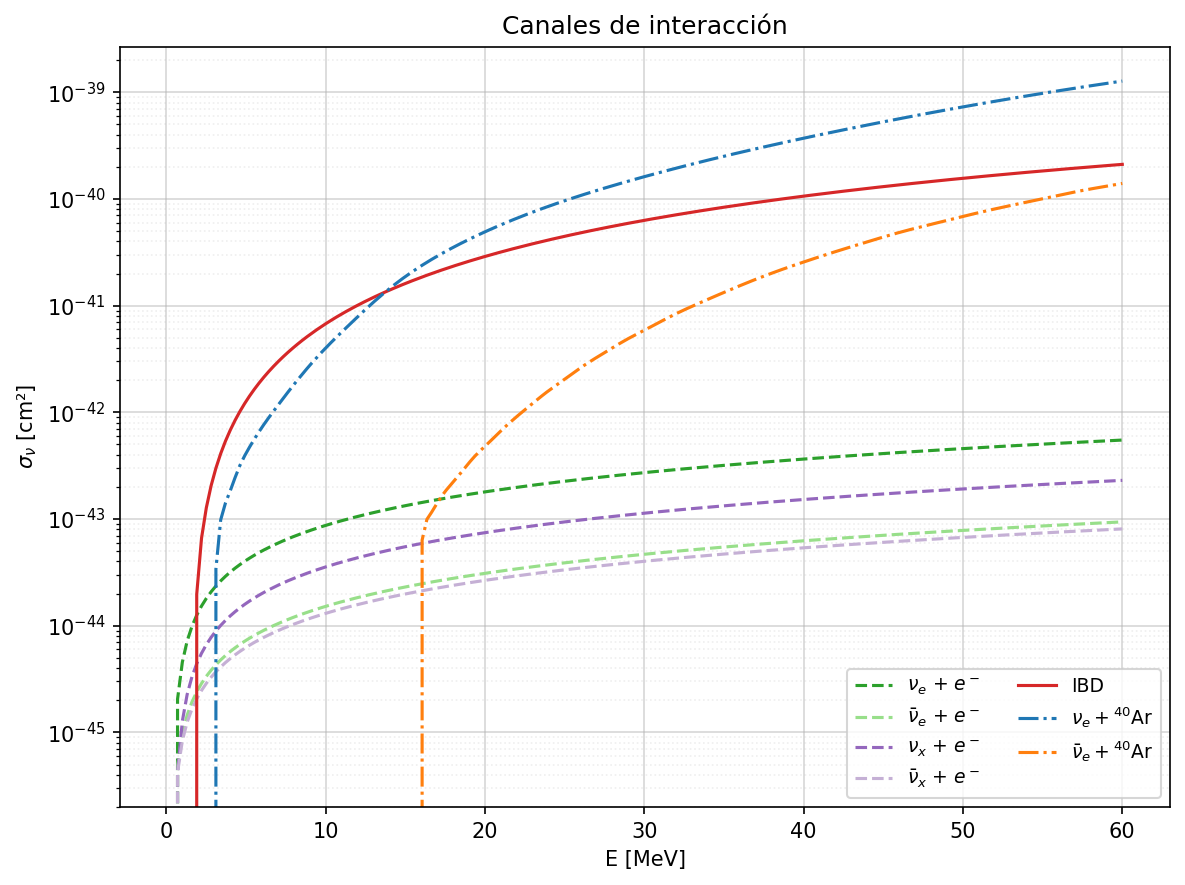

In [11]:
'''
NEUTRINO-ELECTRON SCATTERING
'''
# energias_nes = np.linspace(0.1, 60, 200)*u.MeV
# energias_nes = np.arange(0.1, 60.5, 0.5)*u.MeV

nlista = [r'$\nu_{e}$', r'$\bar{\nu}_{e}$', r'$\nu_{x}$',  r'$\bar{\nu}_{x}$']
colores_es = ['#2ca02c', '#98df8a', '#9467bd', '#c5b0d5'] # Verde y morado

xsec_es = {flavor: None for flavor in Flavor}

for flavor, sabor, color in zip(Flavor, nlista, colores_es):
    canal_es = es.Channel(flavor)
    aux_es = []
    for E_nu in energiatest.value:
        eE_min, eE_max = canal_es.bounds_eE(E_nu)
        sigma = quad(lambda eE: canal_es.dSigma_dE(E_nu, eE) * factor_conversion, eE_min, eE_max)[0]
        aux_es.append(sigma)

    xsec_es[flavor] = np.array(aux_es) * u.cm**2

plt.figure(figsize=(8, 6), dpi=150)
for flavor, color, sabor in zip(Flavor, colores_es, nlista):
    plt.plot(energiatest, xsec_es[flavor], label=f'{sabor} + $e^-$', 
             color=color, ls='--', lw=1.5)
'''
INVERSE BETA DECAY
'''
# e_threshold = ibd.eThr # Sin unidades
# energias_ibd = np.linspace(e_threshold, 60, 200)*u.MeV
# energias_ibd = np.arange(e_threshold, 60.5+e_threshold, 0.5)*u.MeV

# Extraer sección eficaz
canal_ibd = ibd.Channel(Flavor.NU_E_BAR)

aux_ibd = []

for E_nu in energiatest.value:
    # Límites 
    eE_min, eE_max = canal_ibd.bounds_eE(E_nu)
    
    # Se integra la sección (dSigma/dE) 
    # quad devuelve una tupla (data, error)
    sigma_total = quad(lambda eE: canal_ibd.dSigma_dE(E_nu, eE) * factor_conversion, 
                       eE_min, eE_max)[0]
    
    # Se extraen los valores de quad[0] y se almacenan en una lista
    aux_ibd.append(sigma_total) # 

xsec_ibd = np.array(aux_ibd) * u.cm**2

plt.plot(energiatest, xsec_ibd, 
         color='#d62728', lw=1.5,
         label='IBD')
"""
INTERACCIONES EN ARGON
"""
# energias_Ar = np.linspace(0.1, 60, 200)*u.MeV
# energias_Ar = np.arange(0.1, 60.5, 0.5)*u.MeV

# snewpy/snowglobes 
xsec_arnue = rc.load_xsec('nue_Ar40', Flavor.NU_E)(energiatest)
xsec_arnuebar = rc.load_xsec('nuebar_Ar40', Flavor.NU_E_BAR)(energiatest)

plt.plot(energiatest, xsec_arnue, label=r'$\nu_e + ^{40}\mathrm{Ar}$', ls='-.', color='#1f77b4', lw = 1.5)
plt.plot(energiatest, xsec_arnuebar, label=r'$\bar{\nu}_e + ^{40}\mathrm{Ar}$', ls='-.', color='#ff7f0e', lw=1.5)

plt.yscale('log')
plt.xlabel('E [MeV]')
plt.ylabel(r'$\sigma_\nu$ [cm²]')
plt.title('Canales de interacción')
plt.legend(loc='lower right', ncol=2, fontsize=9, 
           framealpha=0.8)

plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.grid(True, which='minor', linestyle=':', alpha=0.2) 

plt.tight_layout()
# plt.savefig('images/xsecs', dpi=300, bbox_inches='tight')
plt.show()

# Tasas de eventos

In [12]:
# def eventos_hyperk(nombre_transformacion):
    
#     P_H = diccionario_PH[nombre_transformacion]
#     flujo_hyperk_nmo, flujo_hyperk_imo = cantidades_en_tierra(P_H)
    
#     # NMO
#     d2NdEdT_nmo = targets_hyperk_ibd * flujo_hyperk_nmo[Flavor.NU_E_BAR] * xsec_ibd
    
#     dNdE_nmo = np.trapezoid(d2NdEdT_nmo, x=t, axis=0)
#     dNdT_nmo = np.trapezoid(d2NdEdT_nmo, x=energiatest, axis=1)
    
#     # IMO
#     d2NdEdT_imo = targets_hyperk_ibd * flujo_hyperk_imo[Flavor.NU_E_BAR] * xsec_ibd
    
#     dNdE_imo = np.trapezoid(d2NdEdT_imo, x=t, axis=0)
#     dNdT_imo = np.trapezoid(d2NdEdT_imo, x=energiatest, axis=1)

#     # Plot
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)
    
#     # Eventos en el tiempo
#     ax1.plot(t, dNdT_nmo, lw=2.5, label=f'NMO (Total: {np.trapezoid(dNdE_nmo, x=energiatest):.0f})')
#     ax1.plot(t, dNdT_imo, lw=2.5, linestyle='--', label=f'IMO (Total: {np.trapezoid(dNdE_imo, x=energiatest):.0f})')
    
#     ax1.set_xlabel(r'$t_{pb}$ [s]')
#     ax1.set_ylabel(r'$\frac{dN}{dt}$ [' + str(dNdT_nmo.unit) + ']')
#     ax1.set_xscale('log')
#     ax1.grid(alpha=0.3, linestyle='--')
#     ax1.legend(loc='upper right')

#     # Eventos por energías
#     ax2.plot(energiatest, dNdE_nmo, lw=2.5, label=f'NMO (Total: {np.trapezoid(dNdE_nmo, x=energiatest):.0f})')
#     ax2.plot(energiatest, dNdE_imo, lw=2.5, linestyle='--', label=f'IMO (Total: {np.trapezoid(dNdE_imo, x=energiatest):.0f})')
    
#     ax2.set_xlabel(r'$E_\nu$ [MeV]')
#     ax2.set_ylabel(r'$\frac{dN}{dE_\nu}$ [' + str(dNdE_imo.unit) + ']')
#     ax2.grid(alpha=0.3, linestyle='--')
#     ax2.legend(loc='upper right')

#     fig.suptitle(f'Hyper-K (Canal IBD) | {nombre_transformacion}', 
#                  fontsize=15, weight='bold')
    
#     plt.tight_layout()
#     plt.show()

# # WIDGETS
# transformacion_dropdown = widgets.Dropdown(
#     options=list(diccionario_PH.keys()),
#     value='Adiabática (PH = 0)',
#     description='Transición:',
#     style={'description_width': '150px'},
#     layout=widgets.Layout(width='600px')
# )

# salida_panel = widgets.interactive_output(
#     eventos_hyperk,
#     {'nombre_transformacion': transformacion_dropdown}
# )

# display(transformacion_dropdown, salida_panel)

In [13]:
canales_deteccion = {
    
    # IBD

    'Hyper-K | Canal IBD ': {
        'targets': targets_hyperk_ibd,
        'xsec': xsec_ibd,
        'flavor': Flavor.NU_E_BAR,
        'tipo': 'cc' 
    },
    'JUNO | Canal IBD': {
        'targets': targets_juno_ibd,
        'xsec': xsec_ibd,
        'flavor': Flavor.NU_E_BAR,
        'tipo': 'cc'
    },
    
    # ARGÓN (CC)
    
    'DUNE | Canal \u03BD\u2091 CC': { # Unicode HTML
        'targets': targets_dune_argon,
        'xsec': xsec_arnue,
        'flavor': Flavor.NU_E,
        'tipo': 'cc'
    },
    'DUNE | Canal \u03BD\u0304\u2091 CC': { # Unicode HTML
        'targets': targets_dune_argon,
        'xsec': xsec_arnuebar,    
        'flavor': Flavor.NU_E_BAR,  
        'tipo': 'cc'
    },
    
    # ES

    'Hyper-K | Canal ES': { # (Agua 188 kt) 
        'targets': targets_hyperk_nes,
        'xsec': xsec_es, 
        'tipo': 'nc' 
    },
    'JUNO | Canal ES': { # (LS 20 kt)
        'targets': targets_juno_nes,
        'xsec': xsec_es,
        'tipo': 'nc'
    },
    'DUNE | Canal ES': { # (Ar 40 kt)
        'targets': targets_dune_nes,
        'xsec': xsec_es,
        'tipo': 'nc'
    }
}

In [14]:
def plot_eventos_general(nombre_transformacion, nombre_canal, distancia_kpc):

    # Flujos en Tierra
    P_H = diccionario_PH[nombre_transformacion]
    flujo_nmo, flujo_imo = cantidades_en_tierra(P_H, distancia_kpc)

    # Detector en particular
    canal = canales_deteccion[nombre_canal]
    targets = canal['targets']

    # Canal en detector
    if canal['tipo'] == 'cc':
        f = canal['flavor']
        d2NdEdT_nmo = targets * flujo_nmo[f] * canal['xsec']
        d2NdEdT_imo = targets * flujo_imo[f] * canal['xsec']
        
    elif canal['tipo'] == 'nc':

        d2NdEdT_nmo = sum(targets * flujo_nmo[f] * canal['xsec'][f] for f in Flavor)
        d2NdEdT_imo = sum(targets * flujo_imo[f] * canal['xsec'][f] for f in Flavor)

    # Se integra en tiempo
    dNdE_nmo = np.trapezoid(d2NdEdT_nmo, x=t, axis=0)
    dNdE_imo = np.trapezoid(d2NdEdT_imo, x=t, axis=0)
    
    # Se integra en energías
    dNdT_nmo = np.trapezoid(d2NdEdT_nmo, x=energiatest, axis=1)
    dNdT_imo = np.trapezoid(d2NdEdT_imo, x=energiatest, axis=1)

    # Eventos totales
    total_nmo = np.trapezoid(dNdE_nmo, x=energiatest)
    total_imo = np.trapezoid(dNdE_imo, x=energiatest)

    # Gráficas
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)
    
    # Eventos en el tiempo
    ax1.plot(t, dNdT_nmo, lw=2.5, label=f'NMO (Total: {total_nmo:.0f})')
    ax1.plot(t, dNdT_imo, lw=2.5, linestyle='--', label=f'IMO (Total: {total_imo:.0f})')
    
    ax1.set_xlabel(r'$t_{pb}$ [s]', fontsize=12)
    ax1.set_ylabel(r'$\frac{dN}{dt}$ [' + str(dNdT_imo.unit) + ']', fontsize=12)
    # ax1.set_xlim(0.001, 10) 
    ax1.set_xscale('log')
    ax1.grid(alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=11)

    # Eventos por energía
    ax2.plot(energiatest, dNdE_nmo, lw=2.5, label=f'NMO (Total: {total_nmo:.0f})')
    ax2.plot(energiatest, dNdE_imo, lw=2.5, linestyle='--', label=f'IMO (Total: {total_imo:.0f})')
    
    ax2.set_xlabel(r'$E_\nu$ [' + str(energiatest.unit) + ']', fontsize=12)
    ax2.set_ylabel(r'$\frac{dN}{dE_\nu}$ [' + str(dNdE_imo.unit) + ']', fontsize=12)
    # ax2.set_xlim(0.1, 60)
    ax2.grid(alpha=0.3, linestyle='--')
    ax2.legend(loc='upper right', fontsize=11)

    # Título
    fig.suptitle(f'{nombre_canal} | Transición: {nombre_transformacion} | d = {distancia_kpc:.2f} kpc \n {modelo_act}', 
                 fontsize=16, weight='bold')
    
    plt.tight_layout()
    plt.show()

# Widgets 
transformacion_dropdown = widgets.Dropdown(
    options=list(diccionario_PH.keys()),
    value='Adiabática (PH = 0)',
    description='Transición:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='300px')
)

canal_dropdown = widgets.Dropdown(
    options=list(canales_deteccion.keys()),
    value=list(canales_deteccion.keys())[0], 
    description='Detector: ',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='300px')
)

distancia_slider = widgets.FloatLogSlider(
    value=10.0,
    base=10,
    min=-1, # 0.1 kpc
    max=3,  # 1000 kpc
    step=0.05,
    description='Distancia [kpc]:',
    readout_format='.2f',
    style={'description_width': '110px'},
    layout=widgets.Layout(width='400px')
)

controles_d1 = widgets.HBox([canal_dropdown, transformacion_dropdown, distancia_slider])

salida_d1 = widgets.interactive_output(
    plot_eventos_general,
    {'nombre_transformacion': transformacion_dropdown,
     'nombre_canal': canal_dropdown,
     'distancia_kpc': distancia_slider}
)

display(controles_d1, salida_d1)

Output()